In [22]:
#Importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib inline

In [23]:
#Read csv file

df = pd.read_csv('diabetes_medication_clinical_trial1_3.csv')

In [24]:
df.head()

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
0,1,treatment,70,Female,10,8.7,8.7,0,NaN
1,2,placebo,46,Male,19,9.9,9.9,0,Fatigue
2,3,treatment,56,Male,17,8.6,8.6,0,NaN
3,4,treatment,59,Male,19,8.9,8.9,0,Headache
4,5,treatment,68,Male,5,9.1,9.1,0,NaN


### Step #2 Data Exploration

In [25]:
#shape of data
print(f"Data Frame shape : {df.shape}")

Data Frame shape : (1400, 9)


In [26]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   object 
 2   age                1400 non-null   int64  
 3   gender             1400 non-null   object 
 4   duration_diabetes  1400 non-null   int64  
 5   initial_hba1c      1400 non-null   float64
 6   hba1c              1400 non-null   float64
 7   time               1400 non-null   int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 98.6+ KB


In [27]:
#Descriptive staistics using describe
df.describe()

,subject_id,age,duration_diabetes,initial_hba1c,hba1c,time
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,55.250000,10.450000,8.465500,7.686029,12.000000
std,57.754936,9.530602,5.805306,0.869367,1.106412,8.002859
min,1.000000,40.000000,1.000000,7.000000,4.700000,0.000000
25%,50.750000,46.000000,5.000000,7.700000,6.980000,4.000000
50%,100.500000,56.000000,11.000000,8.450000,7.700000,12.000000
75%,150.250000,64.000000,16.000000,9.125000,8.500000,20.000000
max,200.000000,70.000000,20.000000,10.000000,10.000000,24.000000


### Step#3 Data Cleaning

In [28]:
#Check missing values
print(f"Missing values :\n {df.isnull().sum()}")

Missing values :
 subject_id              0
group                   0
age                     0
gender                  0
duration_diabetes       0
initial_hba1c           0
hba1c                   0
time                    0
adverse_event        1123
dtype: int64


In [29]:
#Fill missing values in numeric columns only
df = df.dropna()
# Replace NaNs with 0 safely
#df['adverse_event'] = df['adverse_event'].fillna(0)

In [30]:
#Check missing values
df.isnull().sum()

subject_id           0
group                0
age                  0
gender               0
duration_diabetes    0
initial_hba1c        0
hba1c                0
time                 0
adverse_event        0
dtype: int64

In [33]:
#Convert dat type (date time objects)
df['time']= pd.to_numeric(df['time'], errors= 'coerce')

In [34]:
df

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
1,2,placebo,46,Male,19,9.9,9.90,0,Fatigue
3,4,treatment,59,Male,19,8.9,8.90,0,Headache
6,7,treatment,69,Female,12,8.9,8.90,0,Dizziness
7,8,treatment,44,Female,1,8.8,8.80,0,Headache
10,11,treatment,52,Female,2,7.8,7.80,0,Nausea
...,...,...,...,...,...,...,...,...,...
1376,177,treatment,48,Female,7,9.2,6.80,24,Nausea
1380,181,treatment,55,Male,18,8.1,5.70,24,Fatigue
1389,190,placebo,59,Female,1,7.7,6.98,24,Nausea
1394,195,treatment,45,Male,13,9.7,7.30,24,Dizziness


In [36]:
# Convert group to categogrical column
df['group'] = df['group'].astype('category')
df

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
1,2,placebo,46,Male,19,9.9,9.90,0,Fatigue
3,4,treatment,59,Male,19,8.9,8.90,0,Headache
6,7,treatment,69,Female,12,8.9,8.90,0,Dizziness
7,8,treatment,44,Female,1,8.8,8.80,0,Headache
10,11,treatment,52,Female,2,7.8,7.80,0,Nausea
...,...,...,...,...,...,...,...,...,...
1376,177,treatment,48,Female,7,9.2,6.80,24,Nausea
1380,181,treatment,55,Male,18,8.1,5.70,24,Fatigue
1389,190,placebo,59,Female,1,7.7,6.98,24,Nausea
1394,195,treatment,45,Male,13,9.7,7.30,24,Dizziness


In [37]:
df = pd.get_dummies(df , columns = ['group'] , drop_first = True)


In [38]:
df.rename(columns={'group_treatment' : 'group_treatment'}, inplace=True)

In [39]:
df.head()


,subject_id,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event,group_treatment
1,2,46,Male,19,9.9,9.9,0,Fatigue,False
3,4,59,Male,19,8.9,8.9,0,Headache,True
6,7,69,Female,12,8.9,8.9,0,Dizziness,True
7,8,44,Female,1,8.8,8.8,0,Headache,True
10,11,52,Female,2,7.8,7.8,0,Nausea,True


In [41]:
df.columns


Index(['subject_id', 'age', 'gender', 'duration_diabetes', 'initial_hba1c',
       'hba1c', 'time', 'adverse_event', 'group_treatment'],
      dtype='object')

In [42]:
#Convert all columns used in modelling in numeric types
df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

In [43]:
df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')

In [52]:
#Calculate the average hba1c for treatment
avg_hba1c_treatment = df[df['group_treatment']== 1]['hba1c'].mean()
print(f"Average hba1c for Treatment Group: {avg_hba1c_treatment}")

Average hba1c for Treatment Group: 7.35985401459854


In [53]:
#Calculate the average hba1c for placebo group
avg_hba1c_placebo = df[df['group_treatment']== 0]['hba1c'].mean()
print(f"Average Hba1c for placebo group: {avg_hba1c_placebo}")

Average Hba1c for placebo group: 8.139142857142858


In [54]:
#Calculate change in Hb1ac for each subject
df['hba1c_change'] = df.groupby('subject_id')['hba1c'].transform(lambda x:x - x.iloc[0])

In [56]:
#Count occurence of each type of adverse event
adverse_event = df['adverse_event'].value_counts()
print(adverse_event)

adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64


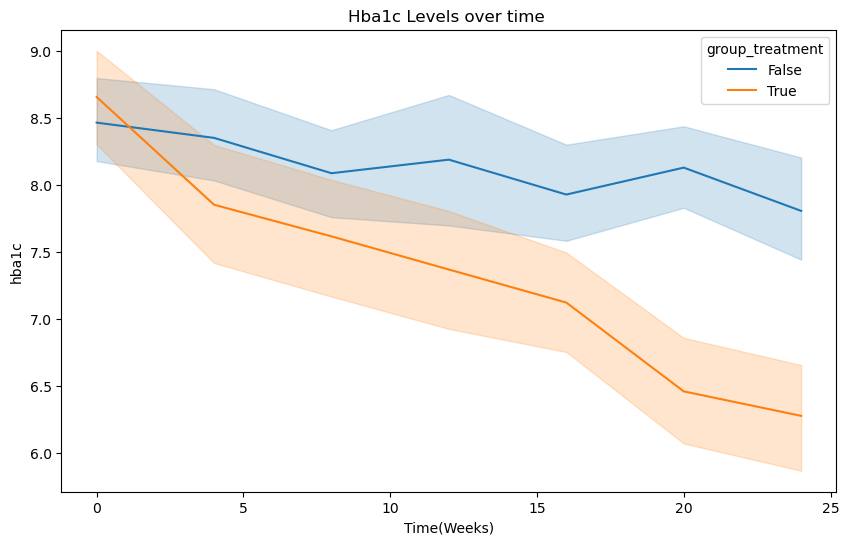

In [57]:
#Plot hba1c levels over time with treatment group color coding
plt.figure(figsize=(10, 6))
sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('Hba1c Levels over time ')
plt.xlabel('Time(Weeks)')
plt.show()

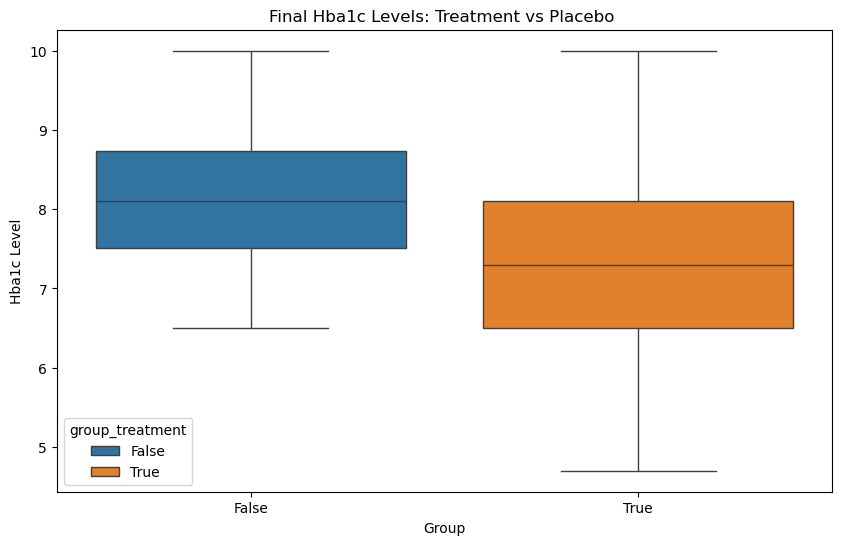

In [61]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='group_treatment', y='hba1c',hue='group_treatment', data=df)
plt.title('Final Hba1c Levels: Treatment vs Placebo ')
plt.xlabel('Group')
plt.ylabel('Hba1c Level')
plt.show()

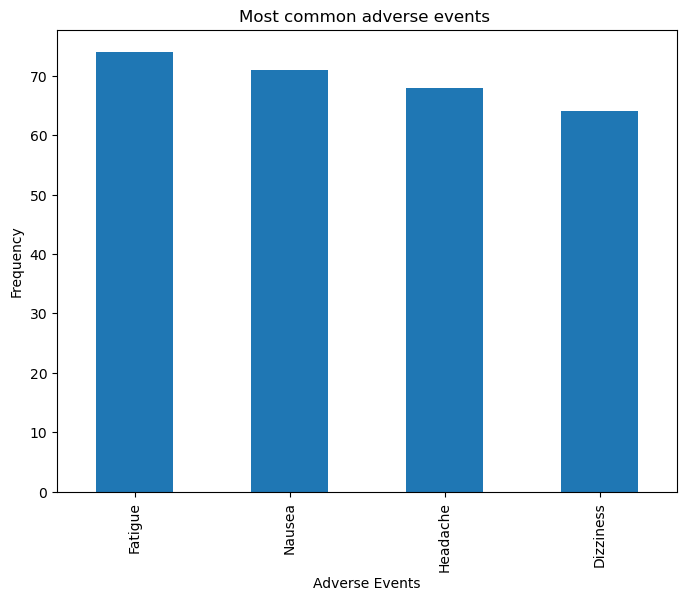

In [64]:
plt.figure(figsize=(8, 6))
adverse_event.plot(kind='bar')
plt.title('Most common adverse events ')
plt.xlabel('Adverse Events')
plt.ylabel('Frequency')
plt.show()

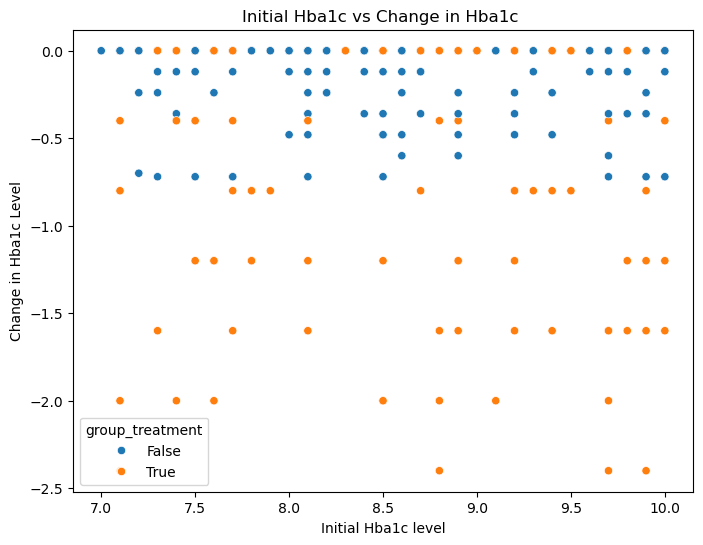

In [65]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change',hue='group_treatment', data=df)
plt.title('Initial Hba1c vs Change in Hba1c ')
plt.xlabel('Initial Hba1c level')
plt.ylabel('Change in Hba1c Level')
plt.show()

In [67]:
#T-test 
t_stat, p_value = stats.ttest_ind(df[df['group_treatment']== 1]['hba1c'], df[df['group_treatment']==0]['hba1c'])
print(f"T test value : {t_stat} , P value : {p_value}")

T test value : -6.200485372339337 , P value : 2.0550724738165274e-09


In [69]:
#Perform Anova using statsmodel formula API
model = smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table = sm.stats.anova_lm(model, type=2)
print(aov_table)

                    df      sum_sq    mean_sq          F        PR(>F)
group_treatment    1.0   42.049976  42.049976  48.712453  2.232988e-11
time               1.0   64.254098  64.254098  74.434639  5.169343e-16
Residual         274.0  236.524596   0.863228        NaN           NaN


In [72]:
#using Chi square test to comapre adverse events between groups
adverse_event_table= pd.crosstab(df['group_treatment'],df['adverse_event'])

In [74]:
#Create a cotigency table for adverse events by treatment group
chi2, p, dof, expected= stats.chi2_contingency(adverse_event_table,correction=False)
print(f"Chi square test result: chi2 {chi2}, P value:{p}")

Chi square test result: chi2 3.453364951919518, P value:0.32686108897063443


In [75]:
if 'age_group' not in df.columns:#check if age group column is missing
    df['age_group']= pd.cut(df['age'], bins=[0,30,60,90], labels=['Young','Middle_age','Old'])


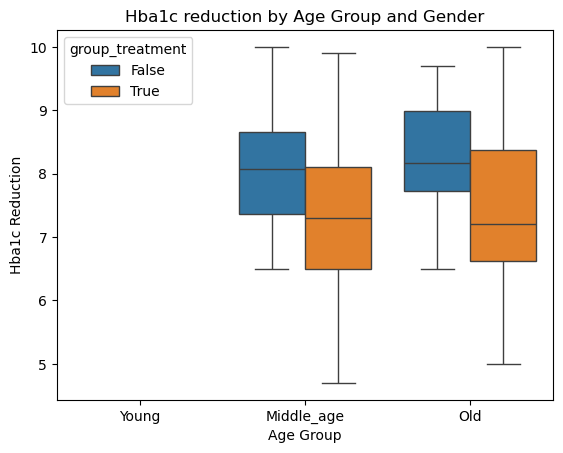

In [76]:
#Create a boxplot for hba1c by age group and treatment group
sns.boxplot(x='age_group', y='hba1c', hue='group_treatment' , data=df)
plt.title('Hba1c reduction by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Hba1c Reduction')
plt.show()

In [78]:
#Calculate the correlation between duration of diabeties and hba1c change
correlation = df['duration_diabetes'].corr(df['hba1c_change'])
print(f"Correlation between duration of Diabetes and Hba1c change: {correlation}")

Correlation between duration of Diabetes and Hba1c change: -0.010949212625554495
